In [1]:
# 单元格1：只导入
import pandas as pd
print('pandas 没问题')

pandas 没问题


In [2]:
# 单元格2：只加载，什么都不做
df = pd.read_pickle(r'E:\datafx\LSWMD.pkl')
print('加载完成')

加载完成


In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载全量
df_full = df[['waferMap', 'lotName', 'failureType']]

# 展平标签
def flatten_label(x):
    arr = np.asarray(x, dtype=object).ravel()
    return arr[0] if arr.size > 0 else 'Unlabeled'

df_full['failureType'] = df_full['failureType'].apply(flatten_label)

print('全量数据:', df_full.shape)
print(df_full['failureType'].value_counts())

# 分层抽样
labeled = df_full[df_full['failureType'] != 'Unlabeled'].sample(30000, random_state=42)
unlabeled = df_full[df_full['failureType'] == 'Unlabeled'].sample(50000, random_state=42)
sub = pd.concat([labeled, unlabeled]).sample(frac=1, random_state=42).reset_index(drop=True)

sub.to_pickle(r'E:\datafx\wm811k_sub.pkl')
print('子集已保存:', sub.shape)

del df_full, labeled, unlabeled, sub

<ipython-input-4-6a3b4f1c6b1b>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full['failureType'] = df_full['failureType'].apply(flatten_label)


全量数据: (811457, 3)
Unlabeled    638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: failureType, dtype: int64
子集已保存: (80000, 3)


In [5]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_pickle(r'E:\datafx\wm811k_sub.pkl')

def calc_yield(wafer_map):
    """良率 = 良品die数 / 有效die数"""
    valid = (wafer_map > 0).sum()
    passed = (wafer_map == 1).sum()
    return passed / valid if valid > 0 else np.nan

df['yield'] = df['waferMap'].apply(calc_yield)

print('晶圆总数:', len(df))
print('平均良率: {:.2%}'.format(df['yield'].mean()))
print('良率中位数: {:.2%}'.format(df['yield'].median()))

晶圆总数: 80000
平均良率: 89.91%
良率中位数: 91.83%


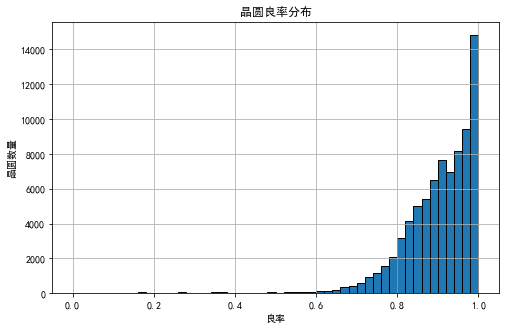

平均良率最低的10个批次:
              mean  count
lotName                  
lot17466  0.176378      5
lot3244   0.336659      6
lot21941  0.353176      5
lot3262   0.354030      5
lot2426   0.355967      5
lot21923  0.362391      5
lot20356  0.375328      5
lot4621   0.401756      5
lot3249   0.421069      5
lot2697   0.445650      5


In [6]:
# 图1：良率分布直方图
fig, ax = plt.subplots(figsize=(8, 5))
df['yield'].hist(bins=50, ax=ax, edgecolor='black')
ax.set_xlabel('良率')
ax.set_ylabel('晶圆数量')
ax.set_title('晶圆良率分布')
fig.savefig('fig1_良率分布.png', dpi=150, bbox_inches='tight')
plt.show()

# 按批次统计，找出平均良率最低的10个批次
lot_yield = df.groupby('lotName')['yield'].agg(['mean', 'count'])
lot_yield = lot_yield[lot_yield['count'] >= 5]  # 批次里至少5张，避免小样本干扰
low_lots = lot_yield.sort_values('mean').head(10)
print('平均良率最低的10个批次:')
print(low_lots)

             count      mean
failureType                 
none         25642  0.894772
Edge-Ring     1600  0.850108
Edge-Loc       858  0.815915
Center         749  0.768131
Loc            662  0.852330
Scratch        232  0.892853
Random         138  0.522206
Donut           88  0.733966
Near-full       31  0.115308


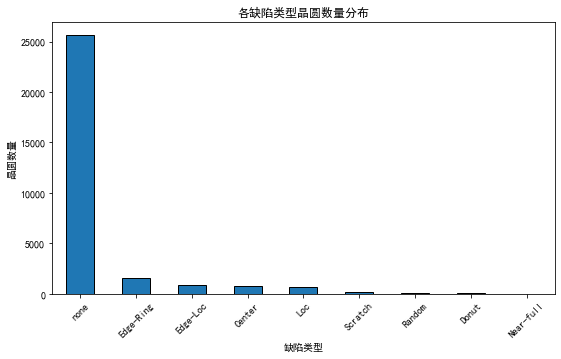

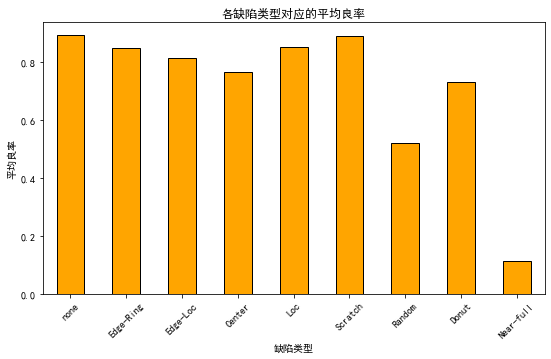

In [7]:
labeled = df[df['failureType'] != 'Unlabeled']

# 各类缺陷的数量和平均良率
summary = labeled.groupby('failureType')['yield'].agg(['count', 'mean'])
summary = summary.sort_values('count', ascending=False)
print(summary)

# 图2：缺陷类型数量分布
fig, ax = plt.subplots(figsize=(9, 5))
summary['count'].plot(kind='bar', ax=ax, edgecolor='black')
ax.set_xlabel('缺陷类型')
ax.set_ylabel('晶圆数量')
ax.set_title('各缺陷类型晶圆数量分布')
plt.xticks(rotation=45)
fig.savefig('fig2_缺陷类型分布.png', dpi=150, bbox_inches='tight')
plt.show()

# 图3：各缺陷类型平均良率对比
fig, ax = plt.subplots(figsize=(9, 5))
summary['mean'].plot(kind='bar', ax=ax, edgecolor='black', color='orange')
ax.set_xlabel('缺陷类型')
ax.set_ylabel('平均良率')
ax.set_title('各缺陷类型对应的平均良率')
plt.xticks(rotation=45)
fig.savefig('fig3_缺陷类型良率.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
def zone_fail_density(wafer_map):
    """把晶圆按半径分成中心/中间/边缘三环，返回每环的不良密度"""
    h, w = wafer_map.shape
    cy, cx = h / 2, w / 2
    yy, xx = np.mgrid[0:h, 0:w]
    r = np.sqrt((yy - cy)**2 + (xx - cx)**2)
    r_max = r[wafer_map > 0].max()

    zones = {'center': r < r_max / 3,
             'middle': (r >= r_max / 3) & (r < 2 * r_max / 3),
             'edge':   r >= 2 * r_max / 3}
    density = {}
    for name, mask in zones.items():
        valid = (mask & (wafer_map > 0)).sum()
        fail = (mask & (wafer_map == 2)).sum()
        density[name] = fail / valid if valid > 0 else 0
    return density

def identify_pattern(density, threshold=2.0):
    """规则判定：某一环的不良密度超过三环均值的threshold倍，判定为该环型缺陷"""
    c, m, e = density['center'], density['middle'], density['edge']
    avg = (c + m + e) / 3
    if avg == 0:
        return 'Clean'
    if e / avg > threshold:
        return 'Edge-type'
    if c / avg > threshold:
        return 'Center-type'
    return 'Uniform/Random'

# 对所有晶圆做判定（8万张大概跑1~2分钟，耐心等）
df['zone_density'] = df['waferMap'].apply(zone_fail_density)
df['auto_pattern'] = df['zone_density'].apply(identify_pattern)

print(df['auto_pattern'].value_counts())

Uniform/Random    68059
Edge-type          6720
Clean              4484
Center-type         737
Name: auto_pattern, dtype: int64


In [13]:
# 把专家标注归成三大类，和自动判定对齐
def map_to_group(ftype):
    if ftype in ('Edge-Ring', 'Edge-Loc'):
        return 'Edge-type'
    elif ftype in ('Center', 'Donut'):
        return 'Center-type'
    else:  # Loc, Random, Scratch, Near-full, None
        return 'Other'

check = df[df['failureType'] != 'Unlabeled'].copy()
check['true_group'] = check['failureType'].apply(map_to_group)
check['pred_group'] = check['auto_pattern'].apply(
    lambda x: x if x in ('Edge-type', 'Center-type') else 'Other')

# 一致率
accuracy = (check['true_group'] == check['pred_group']).mean()
print('自动判定与专家标注一致率: {:.2%}'.format(accuracy))

# 混淆矩阵（看看判错的情况）
print('\n判定结果对照表:')
print(pd.crosstab(check['true_group'], check['pred_group'], normalize='index').round(3))

自动判定与专家标注一致率: 91.10%

判定结果对照表:
pred_group   Center-type  Edge-type  Other
true_group                                
Center-type        0.111      0.000  0.889
Edge-type          0.000      0.446  0.554
Other              0.000      0.021  0.979


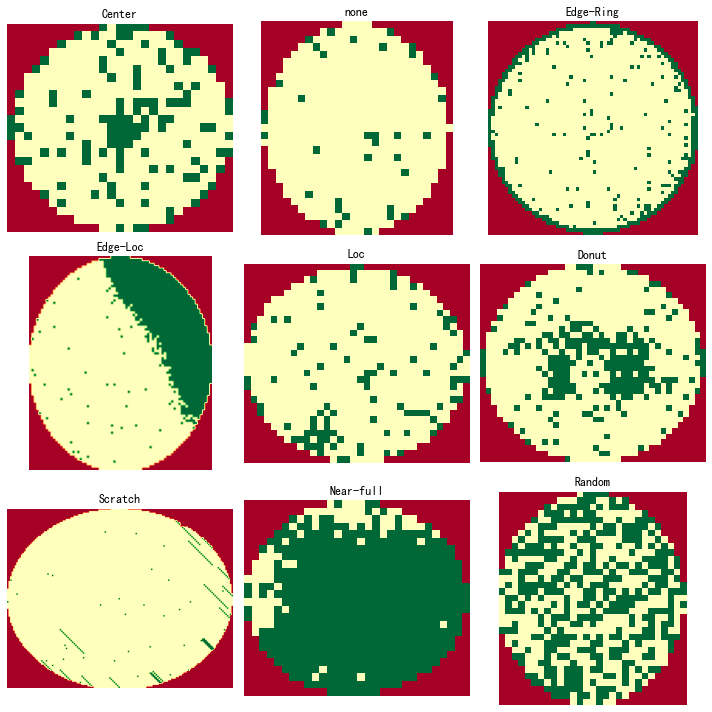

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
types = labeled['failureType'].unique()[:9]
for ax, ftype in zip(axes.flat, types):
    sample = labeled[labeled['failureType'] == ftype].iloc[0]
    ax.imshow(sample['waferMap'], cmap='RdYlGn', vmin=0, vmax=2)
    ax.set_title(ftype)
    ax.axis('off')
plt.tight_layout()
fig.savefig('fig4_缺陷类型晶圆图.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
from matplotlib.backends.backend_pdf import PdfPages
import datetime

with PdfPages('E:\datafx\晶圆测试数据分析报告.pdf') as pdf:
    # 封面页
    fig = plt.figure(figsize=(8.27, 11.69))  # A4
    fig.text(0.5, 0.7, '晶圆测试数据分析报告', size=24, ha='center', weight='bold')
    fig.text(0.5, 0.62, '基于 WM-811K 产线数据集', size=14, ha='center')
    fig.text(0.5, 0.5, f'样本量: {len(df)} 张晶圆', size=12, ha='center')
    fig.text(0.5, 0.46, f'整体平均良率: {df["yield"].mean():.2%}', size=12, ha='center')
    fig.text(0.5, 0.42, f'缺陷自动判定一致率: {accuracy:.2%}', size=12, ha='center')
    fig.text(0.5, 0.3, f'{datetime.date.today()}', size=12, ha='center')
    pdf.savefig(fig)
    plt.close()

    # 把之前保存的图片逐页放进PDF
    for img in ['fig1_良率分布.png', 'fig2_缺陷类型分布.png',
                'fig3_缺陷类型良率.png', 'fig4_缺陷类型晶圆图.png']:
        fig = plt.figure(figsize=(8.27, 11.69))
        plt.imshow(plt.imread(img))
        plt.axis('off')
        pdf.savefig(fig)
        plt.close()

print('报告已生成: 晶圆测试数据分析报告.pdf')

报告已生成: 晶圆测试数据分析报告.pdf
